## Predicting Survival on the Titanic

### History
Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### Assignment:

Build a Machine Learning Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and complete the missing bits of code, to achieve each one of the pipeline steps.

In [39]:
import re

# to handle datasets
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import StandardScaler

# to build the models
from sklearn.linear_model import LogisticRegression

# to evaluate the models
from sklearn.metrics import accuracy_score, roc_auc_score

# to persist the model and the scaler
import joblib

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

## Prepare the data set

In [40]:
# load the data - it is available open source and online

data = pd.read_csv('https://www.openml.org/data/get_csv/16826755/phpMYEkMl')

# display data
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [41]:
# replace interrogation marks by NaN values

data = data.replace('?', np.nan)

In [42]:
# retain only the first cabin if more than
# 1 are available per passenger

def get_first_cabin(row):
    try:
        return row.split()[0]
    except:
        return np.nan
    
data['cabin'] = data['cabin'].apply(get_first_cabin)

In [43]:
# extracts the title (Mr, Ms, etc) from the name variable

def get_title(passenger):
    line = passenger
    if re.search('Mrs', line):
        return 'Mrs'
    elif re.search('Mr', line):
        return 'Mr'
    elif re.search('Miss', line):
        return 'Miss'
    elif re.search('Master', line):
        return 'Master'
    else:
        return 'Other'
    
data['title'] = data['name'].apply(get_title)

In [44]:
# cast numerical variables as floats

data['fare'] = data['fare'].astype('float')
data['age'] = data['age'].astype('float')

In [45]:
# drop unnecessary variables

data.drop(labels=['name','ticket', 'boat', 'body','home.dest'], axis=1, inplace=True)

# display data
data.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,title
0,1,1,female,29.0000,0,0,211.3375,B5,S,Miss
1,1,1,male,0.9167,1,2,151.5500,C22,S,Master
2,1,0,female,2.0000,1,2,151.5500,C22,S,Miss
3,1,0,male,30.0000,1,2,151.5500,C22,S,Mr
4,1,0,female,25.0000,1,2,151.5500,C22,S,Mrs


In [46]:
# save the data set

data.to_csv('titanic.csv', index=False)

## Data Exploration

### Find numerical and categorical variables

In [47]:
data.shape

(1309, 10)

In [48]:
target = 'survived'

In [49]:
vars_num = data.select_dtypes('number').columns

vars_cat = data.select_dtypes(include='object').columns

print('Number of numerical variables: {}'.format(len(vars_num)))
print('Number of categorical variables: {}'.format(len(vars_cat)))

Number of numerical variables: 6
Number of categorical variables: 4


C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\2298298959.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = data.select_dtypes(include='object').columns


### Find missing values in variables

In [50]:
# first in numerical variables
print(data.select_dtypes(include=['number']).isnull().sum())

pclass        0
survived      0
age         263
sibsp         0
parch         0
fare          1
dtype: int64


In [51]:
# now in categorical variables
print(data.select_dtypes(include=['object', 'category']).isnull().sum())



sex            0
cabin       1014
embarked       2
title          0
dtype: int64


C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\556643065.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.select_dtypes(include=['object', 'category']).isnull().sum())


### Determine cardinality of categorical variables

C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\3629096910.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=['object', 'category']).columns


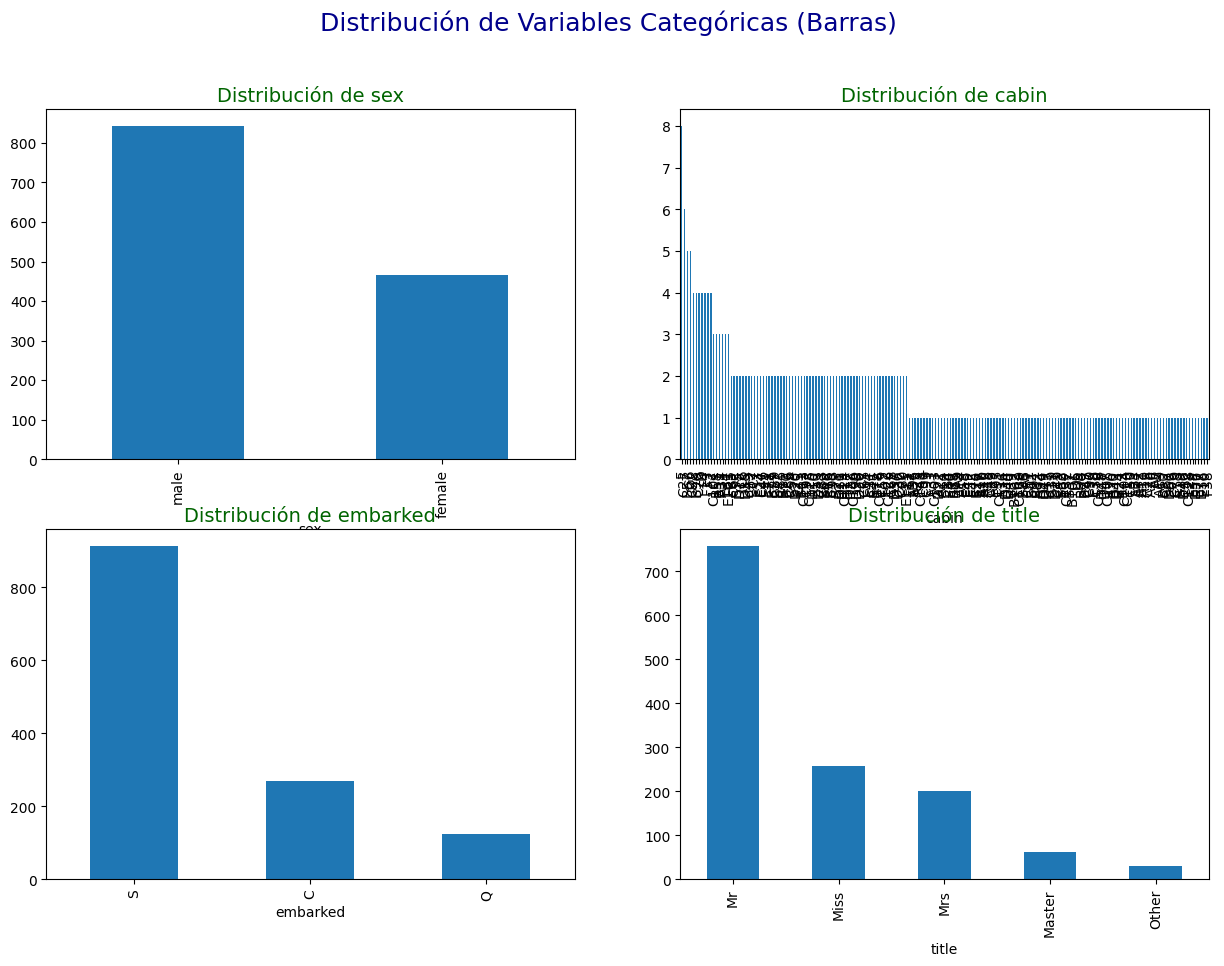

In [52]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns

plt.figure(figsize=(15, 10))
plt.suptitle('Distribución de Variables Categóricas (Barras)', fontsize=18, y=0.98, color='darkblue')

for i, col in enumerate(categorical_vars, 1):
    plt.subplot(2, 2, i)
    data[col].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {col}', fontsize=14, color='darkgreen')

### Determine the distribution of numerical variables

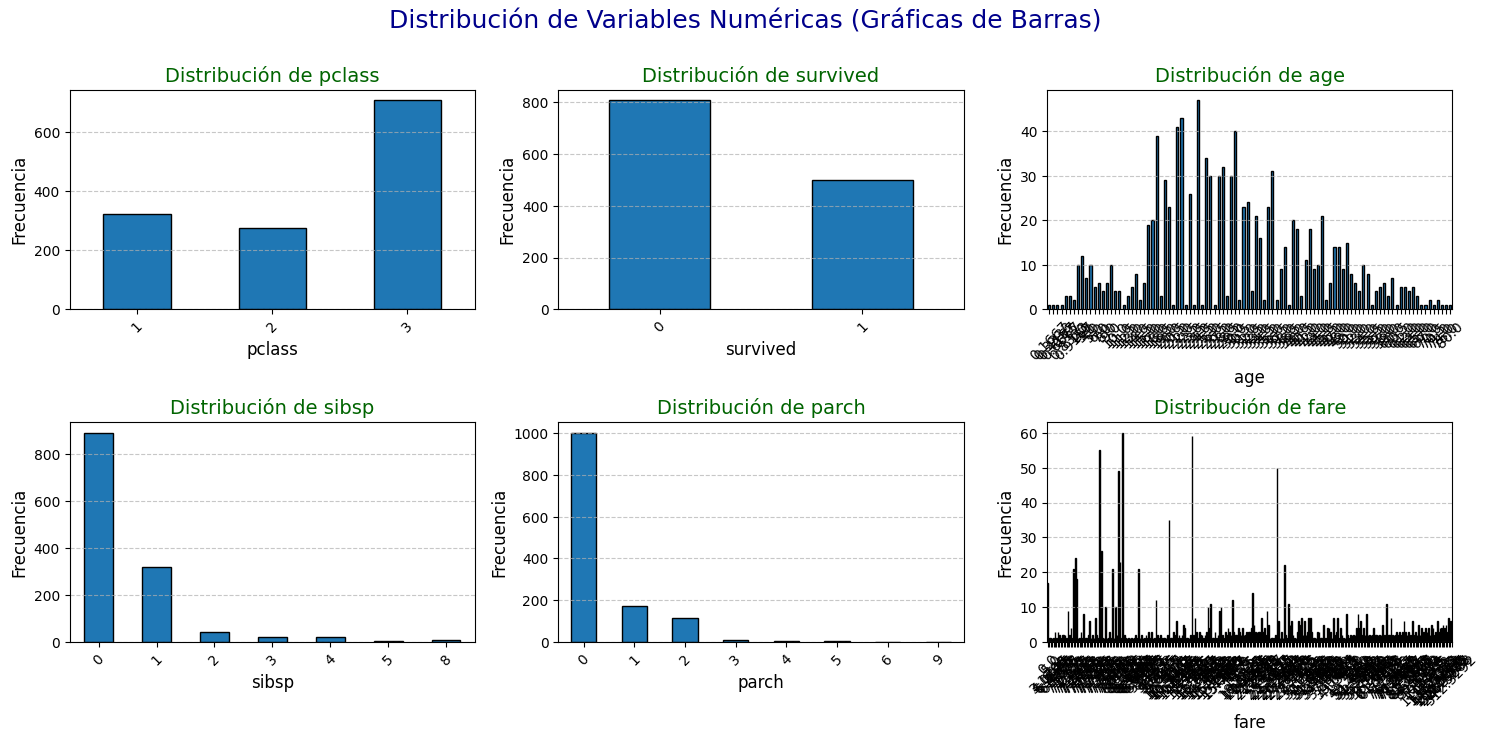

In [53]:
numerical_vars = data.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))
plt.suptitle('Distribución de Variables Numéricas (Gráficas de Barras)', fontsize=18, y=0.98, color='darkblue')

for i, col in enumerate(numerical_vars, 1):
    plt.subplot((len(numerical_vars)//3)+1, 3, i)
    
    data[col].value_counts().sort_index().plot(kind='bar', edgecolor='black')
    
    plt.title(f'Distribución de {col}', fontsize=14, color='darkgreen')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

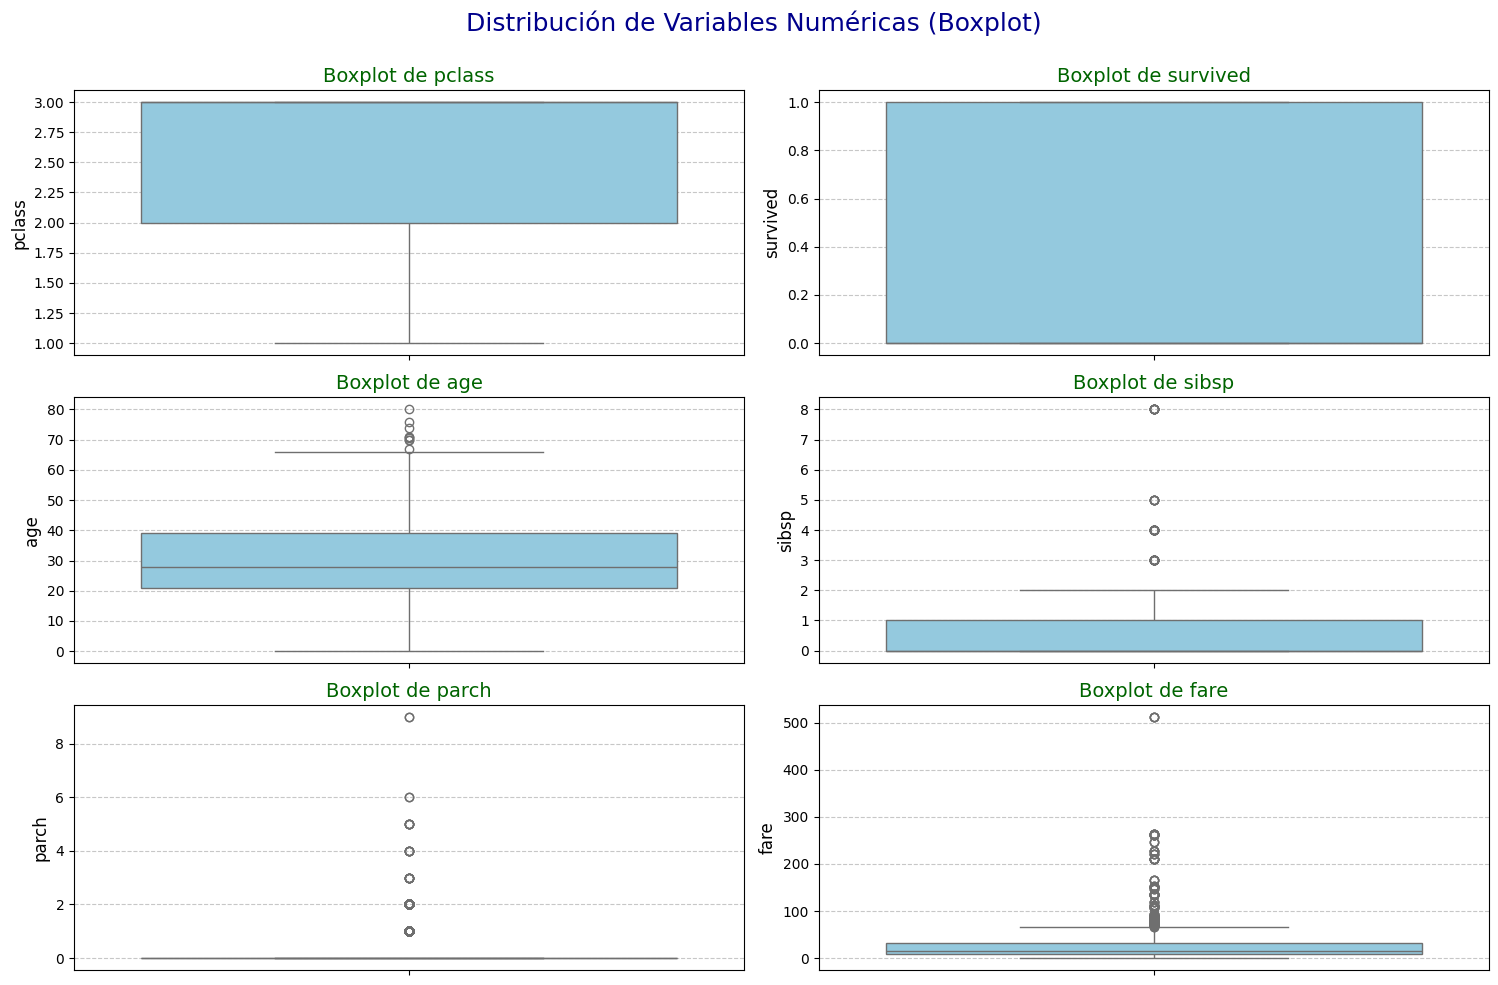

In [54]:
import seaborn as sns 
numerical_vars = data.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))
plt.suptitle('Distribución de Variables Numéricas (Boxplot)', fontsize=18, y=0.98, color='darkblue')

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=data[col], color='skyblue')
    
    plt.title(f'Boxplot de {col}', fontsize=14, color='darkgreen')
    plt.ylabel(col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

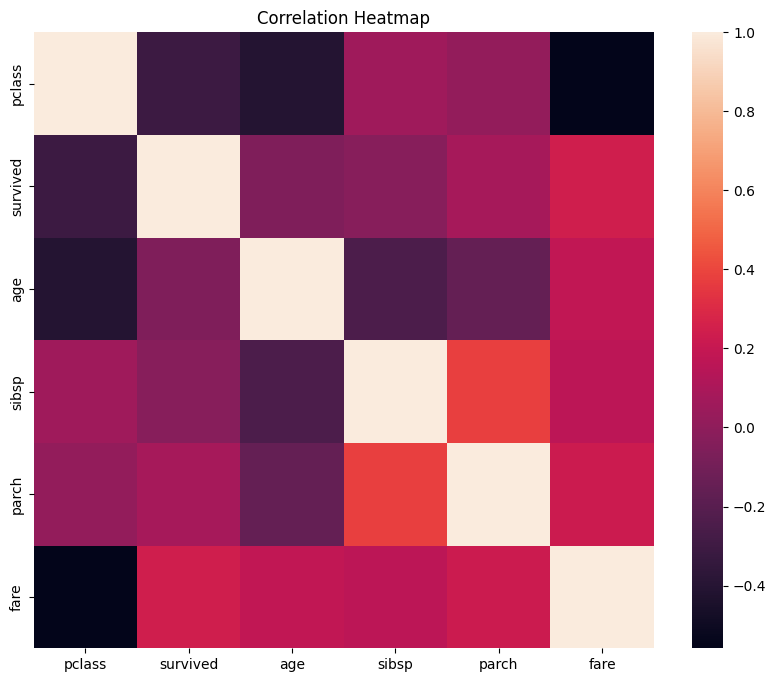

In [55]:
# revisión de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_vars].corr())
plt.title('Correlation Heatmap')

In [56]:
data.shape

(1309, 10)

## Feature Engineering

### Extract only the letter (and drop the number) from the variable Cabin

In [57]:
print(data['cabin'].head(10))

0      B5
1     C22
2     C22
3     C22
4     C22
5     E12
6      D7
7     A36
8    C101
9     NaN
Name: cabin, dtype: str


In [58]:
data['cabin_letter'] = data['cabin'].str.extract(r'([A-Za-z])')

In [59]:
print(data['cabin_letter'].head(10))

0      B
1      C
2      C
3      C
4      C
5      E
6      D
7      A
8      C
9    NaN
Name: cabin_letter, dtype: str


### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [60]:
#Add a binary missing indicator

numerical_vars = data.select_dtypes(include='number').columns

for col in numerical_vars:
    data[col + '_missing'] = np.where(data[col].isnull(), 1, 0)

In [61]:
#Fill NA in original variable with the median

numerical_vars = data.select_dtypes(include='number').columns

for col in numerical_vars:
    data[col] = data[col].fillna(data[col].median())

### Replace Missing data in categorical variables with the string **Missing**

In [62]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns

data[categorical_vars] = data[categorical_vars].fillna('Missing')

C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\2905237891.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=['object', 'category']).columns


### Remove rare labels in categorical variables

- remove labels present in less than 5 % of the passengers

In [63]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns

for col in categorical_vars:
    freq = data[col].value_counts(normalize=True)
    rare_labels = freq[freq < 0.05].index
    
    data[col] = data[col].replace(rare_labels, 'Rare')

C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\1080845526.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=['object', 'category']).columns


### Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [64]:
data.head(10)

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,title,cabin_letter,pclass_missing,survived_missing,age_missing,sibsp_missing,parch_missing,fare_missing
0,1,1,female,29.0000,0,0,211.3375,Rare,S,Miss,Rare,0,0,0,0,0,0
1,1,1,male,0.9167,1,2,151.5500,Rare,S,Rare,C,0,0,0,0,0,0
2,1,0,female,2.0000,1,2,151.5500,Rare,S,Miss,C,0,0,0,0,0,0
3,1,0,male,30.0000,1,2,151.5500,Rare,S,Mr,C,0,0,0,0,0,0
4,1,0,female,25.0000,1,2,151.5500,Rare,S,Mrs,C,0,0,0,0,0,0
5,1,1,male,48.0000,0,0,26.5500,Rare,S,Mr,Rare,0,0,0,0,0,0
6,1,1,female,63.0000,1,0,77.9583,Rare,S,Miss,Rare,0,0,0,0,0,0
7,1,0,male,39.0000,0,0,0.0000,Rare,S,Mr,Rare,0,0,0,0,0,0
8,1,1,female,53.0000,2,0,51.4792,Rare,S,Mrs,C,0,0,0,0,0,0
9,1,0,male,71.0000,0,0,49.5042,Missing,C,Mr,Missing,0,0,0,0,0,0


In [65]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns

# One Hot Encoding con k-1 variables binarias
data = pd.get_dummies(data, columns=categorical_vars, drop_first=True)

C:\Users\Angela Cañon\AppData\Local\Temp\ipykernel_11840\247607484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=['object', 'category']).columns


In [66]:
data.head(10)

,pclass,survived,age,sibsp,parch,fare,pclass_missing,survived_missing,age_missing,sibsp_missing,parch_missing,fare_missing,sex_male,cabin_Rare,embarked_Q,embarked_Rare,embarked_S,title_Mr,title_Mrs,title_Rare,cabin_letter_Missing,cabin_letter_Rare
0,1,1,29.0000,0,0,211.3375,0,0,0,0,0,0,False,True,False,False,True,False,False,False,False,True
1,1,1,0.9167,1,2,151.5500,0,0,0,0,0,0,True,True,False,False,True,False,False,True,False,False
2,1,0,2.0000,1,2,151.5500,0,0,0,0,0,0,False,True,False,False,True,False,False,False,False,False
3,1,0,30.0000,1,2,151.5500,0,0,0,0,0,0,True,True,False,False,True,True,False,False,False,False
4,1,0,25.0000,1,2,151.5500,0,0,0,0,0,0,False,True,False,False,True,False,True,False,False,False
5,1,1,48.0000,0,0,26.5500,0,0,0,0,0,0,True,True,False,False,True,True,False,False,False,True
6,1,1,63.0000,1,0,77.9583,0,0,0,0,0,0,False,True,False,False,True,False,False,False,False,True
7,1,0,39.0000,0,0,0.0000,0,0,0,0,0,0,True,True,False,False,True,True,False,False,False,True
8,1,1,53.0000,2,0,51.4792,0,0,0,0,0,0,False,True,False,False,True,False,True,False,False,False
9,1,0,71.0000,0,0,49.5042,0,0,0,0,0,0,True,False,False,False,False,True,False,False,True,False


### Scale the variables

- Use the standard scaler from Scikit-learn

In [67]:
scaler = StandardScaler()

# Escalar todas las variables del dataset
data_scaled = scaler.fit_transform(data)

# Convertir nuevamente a DataFrame para conservar nombres de columnas
data_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

In [68]:
data_scaled.head()

,pclass,survived,age,sibsp,parch,fare,pclass_missing,survived_missing,age_missing,sibsp_missing,parch_missing,fare_missing,sex_male,cabin_Rare,embarked_Q,embarked_Rare,embarked_S,title_Mr,title_Mrs,title_Rare,cabin_letter_Missing,cabin_letter_Rare
0,-1.546098,1.272006,-0.039005,-0.479087,-0.445000,3.442584,0.0,0.0,-0.501432,0.0,0.0,-0.02765,-1.344995,1.853992,-0.32204,-0.039118,0.657394,-1.172894,-0.425920,-0.274947,-1.853992,2.347858
1,-1.546098,1.272006,-2.215952,0.481288,1.866526,2.286639,0.0,0.0,-0.501432,0.0,0.0,-0.02765,0.743497,1.853992,-0.32204,-0.039118,0.657394,-1.172894,-0.425920,3.637068,-1.853992,-0.425920
2,-1.546098,-0.786160,-2.131977,0.481288,1.866526,2.286639,0.0,0.0,-0.501432,0.0,0.0,-0.02765,-1.344995,1.853992,-0.32204,-0.039118,0.657394,-1.172894,-0.425920,-0.274947,-1.853992,-0.425920
3,-1.546098,-0.786160,0.038512,0.481288,1.866526,2.286639,0.0,0.0,-0.501432,0.0,0.0,-0.02765,0.743497,1.853992,-0.32204,-0.039118,0.657394,0.852592,-0.425920,-0.274947,-1.853992,-0.425920
4,-1.546098,-0.786160,-0.349075,0.481288,1.866526,2.286639,0.0,0.0,-0.501432,0.0,0.0,-0.02765,-1.344995,1.853992,-0.32204,-0.039118,0.657394,-1.172894,2.347858,-0.274947,-1.853992,-0.425920


In [69]:
data_scaled.shape

(1309, 22)

In [70]:
data_scaled.dtypes

pclass                  float64
survived                float64
age                     float64
sibsp                   float64
parch                   float64
fare                    float64
pclass_missing          float64
survived_missing        float64
age_missing             float64
sibsp_missing           float64
parch_missing           float64
fare_missing            float64
sex_male                float64
cabin_Rare              float64
embarked_Q              float64
embarked_Rare           float64
embarked_S              float64
title_Mr                float64
title_Mrs               float64
title_Rare              float64
cabin_letter_Missing    float64
cabin_letter_Rare       float64
dtype: object

## Separate data into train and test

Use the code below for reproducibility. Don't change it.

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled.drop('survived', axis=1),  # predictors
    data_scaled['survived_missing'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((1047, 21), (262, 21))

## Train the Logistic Regression model

- Set the regularization parameter to 0.0005
- Set the seed to 0

In [86]:
print(y_train.value_counts())

survived_missing
0.0    1047
Name: count, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split

X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [88]:
# Crear el modelo de regresión logística
log_model = LogisticRegression(
    C=2000,          # inverso de la regularización (1 / 0.0005)
    random_state=0,  # semilla
    max_iter=1000
)

# Entrenar el modelo
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [89]:
print("Clases en y_train:")
print(y_train.value_counts())

Clases en y_train:
survived
0    647
1    400
Name: count, dtype: int64


## Make predictions and evaluate model performance

Determine:
- roc-auc
- accuracy

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [99]:
# Generación de predicciones

# Predicción binaria (0 o 1)
y_pred = log_model.predict(X_test)

# Probabilidad de supervivencia (clase 1)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

In [101]:
#Calcular Precisión - Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.8358778625954199


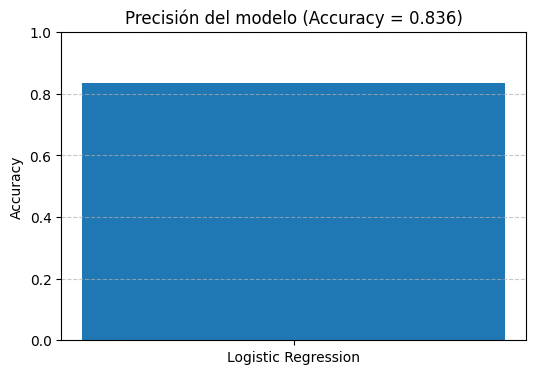

In [102]:
#Graficar Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(['Logistic Regression'], [accuracy])

plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title(f'Precisión del modelo (Accuracy = {accuracy:.3f})')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [103]:
#Calcular ROC

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC del modelo:", roc_auc)

ROC-AUC del modelo: 0.8676234567901235


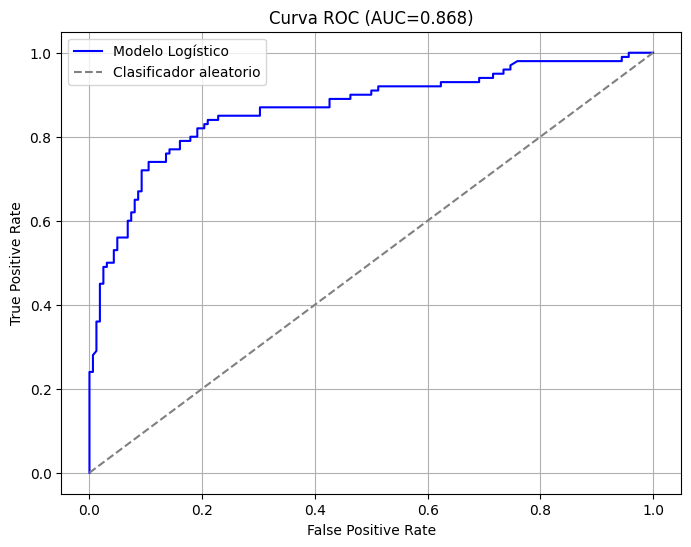

In [104]:
#Graficar ROC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calcular ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Calcular FPR y TPR
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='Modelo Logístico')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Clasificador aleatorio')

# Título con AUC
plt.title(f"Curva ROC (AUC={auc:.3f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.show()

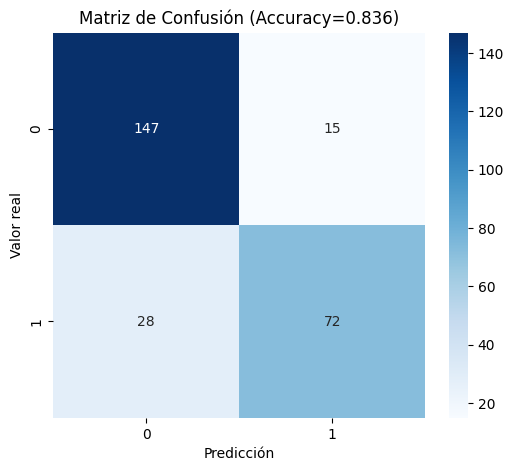

In [105]:
#Generar Matriz de Confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Matriz de Confusión (Accuracy={accuracy:.3f})")
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.show()

That's it! Well done

**Keep this code safe, as we will use this notebook later on, to build production code, in our next assignement!!**